# Generated Summary Token Length Analysis

This notebook computes the average token-level length of generated Chinese summaries on the 50-example gold test set. It compares mBART, BART+Helsinki, agentic LLM pipelines, and the gold reference summaries.

Tokenization note: when `jieba` is installed, Chinese summaries are segmented with `jieba.lcut`. If `jieba` is unavailable, the notebook falls back to a deterministic regex tokenizer that counts each CJK character, each contiguous Latin/number span, and each placeholder as one token while excluding punctuation and whitespace.

In [3]:
from pathlib import Path
import json
import os
import re
import unicodedata

import pandas as pd

In [4]:
def find_project_root(start: Path = Path.cwd()) -> Path:
    """Find the repository root from a notebook or script working directory."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/ and notebooks/.")


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "evaluation" / "gold_length" / "length_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Keep Matplotlib cache inside the writable project tree when plotting later.
MPLCONFIGDIR = OUTPUT_DIR / "matplotlib_cache"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

print("Project root:", PROJECT_ROOT)
print("Output dir:", OUTPUT_DIR)

Project root: /Users/yunu919/Desktop/CLMS/LING573/573ChineseEnglishSummarization
Output dir: /Users/yunu919/Desktop/CLMS/LING573/573ChineseEnglishSummarization/notebooks/evaluation/gold_length/length_analysis


## Source Files

`summary_field` identifies the Chinese summary text to measure in each file. For baseline JSON files this is usually `predicted_zh`; for the gold reference it is `summary_zh`; for agentic JSONL outputs it is `final_summary`.

In [5]:
SOURCES = [
    {
        "model": "mBART",
        "path": "data/gold_results/mbart/mbart_gold_50_results.json",
        "summary_field": "predicted_zh",
    },
    {
        "model": "BART + Helsinki (ST)",
        "path": "data/gold_results/bart_helsinki/bart_helsinki_gold_50_results.json",
        "summary_field": "predicted_zh",
    },
    {
        "model": "Qwen 3.5: 27b (Dir)",
        "path": "notebooks/agents/results/full/direct/qwen/direct_qwen_50samples.jsonl",
        "summary_field": "final_summary",
    },
    {
        "model": "Qwen 3.5: 27b (ST)",
        "path": "notebooks/agents/results/full/summarize_then_translate/qwen/st_qwen_50samples.jsonl",
        "summary_field": "final_summary",
    },
    {
        "model": "Qwen 3.5: 27b (TS)",
        "path": "notebooks/agents/results/full/translate_then_summarize/qwen/ts_qwen_50samples.jsonl",
        "summary_field": "final_summary",
    },
    {
        "model": "Qwen 3.5: 27b (Sem)",
        "path": "notebooks/agents/results/full/semantic/qwen/semantic_qwen27b_50samples.jsonl",
        "summary_field": "final_summary",
    },
    {
        "model": "Gemma 3: 27b (Dir)",
        "path": "notebooks/agents/results/full/direct/gemma/direct_gemma27b_50samples.jsonl",
        "summary_field": "final_summary",
    },
    {
        "model": "Gemma 3: 27b (ST)",
        "path": "notebooks/agents/results/full/summarize_then_translate/gemma/st_gemma27b_50samples.jsonl",
        "summary_field": "final_summary",
    },
    {
        "model": "Gemma 3: 27b (TS)",
        "path": "notebooks/agents/results/full/translate_then_summarize/gemma/ts_gemma27b_50samples.jsonl",
        "summary_field": "final_summary",
    },
    {
        "model": "Gemma 3: 27b (Sem)",
        "path": "notebooks/agents/results/full/semantic/gemma/semantic_gemma27b_50samples.jsonl",
        "summary_field": "final_summary",
    },
    {
        "model": "Aya-Expanse: 32b (Dir)",
        "path": "notebooks/agents/results/full/direct/aya/direct_aya32b_50samples.jsonl",
        "summary_field": "final_summary",
    },
    {
        "model": "Aya-Expanse: 32b (ST)",
        "path": "notebooks/agents/results/full/summarize_then_translate/aya/st_aya32b_50samples.jsonl",
        "summary_field": "final_summary",
    },
    {
        "model": "Aya-Expanse: 32b (TS)",
        "path": "notebooks/agents/results/full/translate_then_summarize/aya/ts_aya32b_50samples.jsonl",
        "summary_field": "final_summary",
    },
    {
        "model": "Aya-Expanse: 32b (Sem)",
        "path": "notebooks/agents/results/full/semantic/aya/semantic_aya32b_50samples.jsonl",
        "summary_field": "final_summary",
    },
    {
        "model": "Golden Length",
        "path": "data/gold_results/gold_set_50_zh_XSAMSum_bart.json",
        "summary_field": "summary_zh",
    },
]

In [6]:
def load_records(path: Path) -> list[dict]:
    """Load records from a JSON list, JSON dict, or JSONL file."""
    if path.suffix == ".jsonl":
        with path.open(encoding="utf-8") as f:
            return [json.loads(line) for line in f if line.strip()]

    with path.open(encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, list):
        return data
    if isinstance(data, dict):
        for value in data.values():
            if isinstance(value, list) and all(isinstance(item, dict) for item in value):
                return value
        return [data]
    raise TypeError(f"Unsupported JSON structure in {path}")


def get_summary(record: dict, field: str) -> str:
    value = record.get(field, "")
    if value is None:
        return ""
    return str(value).strip()

## Tokenization

The primary tokenizer is `jieba` because these summaries are Chinese. The fallback keeps the notebook runnable without installing extra packages.

In [7]:
try:
    import jieba

    TOKENIZER_NAME = "jieba.lcut"
except ModuleNotFoundError:
    jieba = None
    TOKENIZER_NAME = "regex fallback: CJK char / Latin span / number span / placeholder"


TOKEN_RE = re.compile(
    r"<[^>\s]+>|[A-Za-z]+(?:[-'][A-Za-z]+)*|\d+(?:\.\d+)?|[\u3400-\u9fff]|[^\s]"
)


def is_countable_token(token: str) -> bool:
    """Exclude whitespace, punctuation-only, and symbol-only tokens."""
    token = token.strip()
    if not token:
        return False
    return any(not unicodedata.category(ch).startswith(("P", "S", "Z")) for ch in token)


def tokenize_summary(text: str) -> list[str]:
    text = str(text or "").strip()
    if not text:
        return []

    if jieba is not None:
        raw_tokens = jieba.lcut(text)
    else:
        raw_tokens = TOKEN_RE.findall(text)

    return [tok.strip() for tok in raw_tokens if is_countable_token(tok)]


def token_length(text: str) -> int:
    return len(tokenize_summary(text))


print("Tokenizer:", TOKENIZER_NAME)
print("Example tokens:", tokenize_summary("马克向安妮隐瞒了自己的年龄。他40岁了。"))

/Applications/anaconda3/envs/nlp/lib/python3.11/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...


Tokenizer: jieba.lcut


Dumping model to file cache /var/folders/wv/6g0vndhj1918ng7mb558jqbh0000gn/T/jieba.cache
Loading model cost 0.237 seconds.
Prefix dict has been built successfully.


Example tokens: ['马克', '向', '安妮', '隐瞒', '了', '自己', '的', '年龄', '他', '40', '岁', '了']


In [8]:
summary_rows = []
per_example_rows = []

for source in SOURCES:
    path = PROJECT_ROOT / source["path"]
    if not path.exists():
        raise FileNotFoundError(path)

    records = load_records(path)
    lengths = []

    for row_idx, record in enumerate(records):
        summary_text = get_summary(record, source["summary_field"])
        length = token_length(summary_text)
        lengths.append(length)

        per_example_rows.append(
            {
                "model": source["model"],
                "row_idx": row_idx,
                "test_index": record.get("test_index", ""),
                "summary_field": source["summary_field"],
                "summary_text": summary_text,
                "summary_tokens": length,
                "source_file": source["path"],
            }
        )

    length_series = pd.Series(lengths, dtype="float")
    summary_rows.append(
        {
            "Model": source["model"],
            "Generated summary length": round(length_series.mean(), 2),
            "n": int(length_series.count()),
            "std": round(length_series.std(ddof=1), 2),
            "median": round(length_series.median(), 2),
            "min": int(length_series.min()),
            "max": int(length_series.max()),
            "summary_field": source["summary_field"],
            "source_file": source["path"],
        }
    )

summary_df = pd.DataFrame(summary_rows)
per_example_df = pd.DataFrame(per_example_rows)

display(summary_df)

,Model,Generated summary length,n,std,median,min,max,summary_field,source_file
0,mBART,12.60,50,6.02,11.0,4,31,predicted_zh,data/gold_results/mbart/mbart_gold_50_results....
1,BART + Helsinki (ST),11.80,50,4.30,12.0,4,26,predicted_zh,data/gold_results/bart_helsinki/bart_helsinki_...
2,Qwen 3.5: 27b (Dir),23.76,50,7.04,23.5,11,42,final_summary,notebooks/agents/results/full/direct/qwen/dire...
3,Qwen 3.5: 27b (ST),27.32,50,11.23,25.0,7,50,final_summary,notebooks/agents/results/full/summarize_then_t...
4,Qwen 3.5: 27b (TS),24.20,50,5.99,25.5,12,39,final_summary,notebooks/agents/results/full/translate_then_s...
5,Qwen 3.5: 27b (Sem),17.78,50,4.14,18.0,11,28,final_summary,notebooks/agents/results/full/semantic/qwen/se...
6,Gemma 3: 27b (Dir),23.64,50,6.67,23.0,12,40,final_summary,notebooks/agents/results/full/direct/gemma/dir...
7,Gemma 3: 27b (ST),32.50,50,11.81,32.0,9,62,final_summary,notebooks/agents/results/full/summarize_then_t...
8,Gemma 3: 27b (TS),19.40,50,5.85,19.5,4,33,final_summary,notebooks/agents/results/full/translate_then_s...
9,Gemma 3: 27b (Sem),15.96,50,4.70,15.0,9,30,final_summary,notebooks/agents/results/full/semantic/gemma/s...


In [9]:
# Compact two-column table matching the report screenshot.
report_table = summary_df[["Model", "Generated summary length"]].copy()
display(report_table)

,Model,Generated summary length
0,mBART,12.60
1,BART + Helsinki (ST),11.80
2,Qwen 3.5: 27b (Dir),23.76
3,Qwen 3.5: 27b (ST),27.32
4,Qwen 3.5: 27b (TS),24.20
5,Qwen 3.5: 27b (Sem),17.78
6,Gemma 3: 27b (Dir),23.64
7,Gemma 3: 27b (ST),32.50
8,Gemma 3: 27b (TS),19.40
9,Gemma 3: 27b (Sem),15.96


In [10]:
summary_csv = OUTPUT_DIR / "generated_summary_token_length_summary.csv"
per_example_csv = OUTPUT_DIR / "generated_summary_token_lengths_per_example.csv"

summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")
per_example_df.to_csv(per_example_csv, index=False, encoding="utf-8-sig")

print("Saved summary table to:", summary_csv)
print("Saved per-example lengths to:", per_example_csv)

Saved summary table to: /Users/yunu919/Desktop/CLMS/LING573/573ChineseEnglishSummarization/notebooks/evaluation/gold_length/length_analysis/generated_summary_token_length_summary.csv
Saved per-example lengths to: /Users/yunu919/Desktop/CLMS/LING573/573ChineseEnglishSummarization/notebooks/evaluation/gold_length/length_analysis/generated_summary_token_lengths_per_example.csv


Matplotlib is building the font cache; this may take a moment.


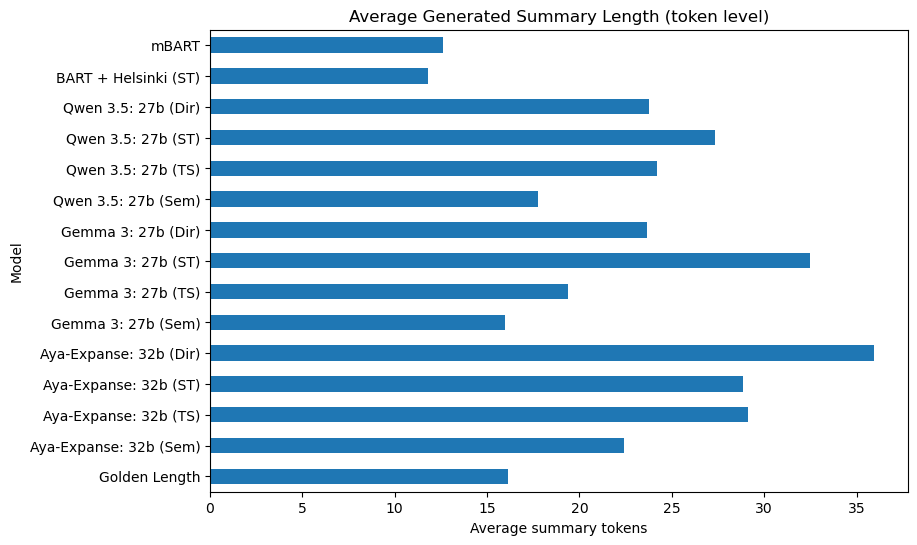

In [11]:
ax = report_table.set_index("Model")["Generated summary length"].plot(
    kind="barh",
    figsize=(9, 6),
    title="Average Generated Summary Length (token level)",
)
ax.set_xlabel("Average summary tokens")
ax.invert_yaxis()